# ML Homework 3 Guide

1. Save a copy of this ipynb file in your GoogleDrive or PC.
2. Edit the name of this code from "HW3.ipynb" to "HW3_(your name).ipynb"
3. Fill out the code cells below according to descriptions.
4. Save and upload to BrightSpace. (DO NOT clear the outputs of your code)
5. Convert the .ipynb file to PDF file and upload together

# [HW 3] Customize the ANN

1. Load dataset resulted from ML3_Code2 (FeatureSelected) and create corresponding labels referring to ML5_Code1.

2. Design and train a customized ANN model according to the following instructions:

- Set the learning rate to 0.01.
- Set the number of hidden layers to 3.
- Set the number of neurons in the first hidden layer to 15.
- Set the number of neurons in the second hidden layer to 10.
- Set the number of neurons in the third hidden layer to 5.
- Set the number of training epochs to 300.
- Set the activation function differently from the ML5 code by referring to the link provided in the code. (Few functions may not work due to compatibility issues, please try other functions in that case.)
- Set the loss function and optimization algorithm differently from the ML5 code by referring to the link provided. (Few functions may not work due to compatibility issues, please try other functions in that case.)

3. Plot a graph of the training process (Loss, Accuracy) at the end.

# Import Packages

In [ ]:
# Start with importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Tensorflow Packages
import tensorflow as tf
from tensorflow import keras
# Sklearn packages
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
# Check if a GPU(in Google server) is allocated
device_name = tf.test.gpu_device_name()
if device_name != "/device:GPU:0":
    raise SystemError("GPU device not found")

print("Found GPU at: {}".format(device_name))

Found GPU at: /device:GPU:0


In [16]:
# Acess to google drive
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# Load the SELECTED (Top 30) Feature Dataset

In [22]:
# Import dataset from ML3_Code2 Per HW Requirement 1
FeatureSelected = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/SavedFiles/ME 597 IIoT/FeatureSelected.csv",
    header=None,
)
FeatureSelected = FeatureSelected.T
FeatureSelected.shape

(360, 30)

In [23]:
# Standardize feature values
FeatureSelected_std = StandardScaler().fit_transform(FeatureSelected)
FeatureSelected_std.shape

(360, 30)

# Split Training & Test Data

In [24]:
# Number of data for each condition: 180
NoOfData = int(FeatureSelected_std.shape[0] / 2)

NormalSet = FeatureSelected_std[:NoOfData, :]
AbnormalSet = FeatureSelected_std[NoOfData:, :]

NormalSet.shape, AbnormalSet.shape

((180, 30), (180, 30))

In [25]:
# Designate test data ratio
TestData_Ratio = 0.2

TrainData_Nor, TestData_Nor = train_test_split(
    NormalSet, test_size=TestData_Ratio, random_state=777
)
TrainData_Abn, TestData_Abn = train_test_split(
    AbnormalSet, test_size=TestData_Ratio, random_state=777
)

# Data and Label Preparation

In [26]:
# One-hot Encoding
TrainLabel_Nor = np.zeros((TrainData_Nor.shape[0], 2))
TrainLabel_Abn = np.ones((TrainData_Abn.shape[0], 2))
TestLabel_Nor = np.zeros((TestData_Nor.shape[0], 2))
TestLabel_Abn = np.ones((TestData_Abn.shape[0], 2))

TrainLabel_Nor[:, 0] = 1  # [1,0]: Normal
TrainLabel_Abn[:, 0] = 0  # [0,1]: Abnormal
TestLabel_Nor[:, 0] = 1  # [1,0]: Normal
TestLabel_Abn[:, 0] = 0  # [0,1]: Abnormal

# Preparation
TrainData = np.concatenate([TrainData_Nor, TrainData_Abn], axis=0)
TestData = np.concatenate([TestData_Nor, TestData_Abn], axis=0)
TrainLabel = np.concatenate([TrainLabel_Nor, TrainLabel_Abn], axis=0)
TestLabel = np.concatenate([TestLabel_Nor, TestLabel_Abn], axis=0)

# Set ANN Parameters
Per HW Requirement 2:
- Set the learning rate to 0.01.
- Set the number of neurons in the first hidden layer to 15.
- Set the number of neurons in the second hidden layer to 10.
- Set the number of neurons in the third hidden layer to 5.
- Set the number of training epochs to 300.

In [27]:
LEARNING_RATE = 0.01
NEURONS_IN_FIRST_HIDDEN_LAYER = 15
NEURONS_IN_SECOND_HIDDEN_LAYER = 10
NEURONS_IN_THIRD_HIDDEN_LAYER = 5
EPOCHS = 300

# Design NEW ANN Architecture
Per HW Requirement 2:
- Set the number of hidden layers to 3.
- Set the activation function differently from the ML5 code by referring to the [link provided in the code](https://keras.io/api/layers/activations/).
  - For this homework, I will use the Gaussian Error Linear Unit (GELU) activation function for the three hidden layers
  - I will use the softplus activation function for the output layer.
- Set the [loss function](https://keras.io/api/losses/probabilistic_losses/) and [optimization algorithm](https://keras.io/api/optimizers/) differently from the ML5 code by referring to the link provided.
  - For this homework, I will switch to the CategoricalFocalCrossentropy loss function.
  - For this homework I will change the optimizer algorithm to the Adamax algorithm.

In [28]:
def ANN_model(input_data):
    keras.backend.clear_session()  # clearing the Keras backend session (initiating variables)

    model = keras.Sequential()
    # Input  Layer
    model.add(
        keras.layers.InputLayer(input_shape=(input_data.shape[1],))
    )

    # Hidden Layer 1
    model.add(
        keras.layers.Dense(
            units=NEURONS_IN_FIRST_HIDDEN_LAYER,
            activation=keras.activations.gelu,
            name="Hidden1",
        )
    )

    # Hidden Layer 2
    model.add(
        keras.layers.Dense(
            units=NEURONS_IN_SECOND_HIDDEN_LAYER,
            activation=keras.activations.gelu,
            name="Hidden2",
        )
    )

    # Hidden Layer 3 - New requirement for homework
    model.add(
        keras.layers.Dense(
            units=NEURONS_IN_THIRD_HIDDEN_LAYER,
            activation=keras.activations.gelu,
            name="Hidden3",
        )
    )

    # Output Layer
    model.add(
        keras.layers.Dense(
            units=2, activation=keras.activations.softplus, name="Output"
        )
    )

    model.compile(
        # Optimization algorithm
        optimizer=keras.optimizers.Adamax(
            learning_rate=LEARNING_RATE
        ),
        loss=keras.losses.CategoricalFocalCrossentropy(),  # Loss function (objective function of Optimization)
        metrics=["accuracy"],
    )  # Metrics to measure during the training process
    return model

In [29]:
# Check the model architecture and the number of parameters
AnnModel = ANN_model(TrainData)
AnnModel.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden1 (Dense)                 │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden2 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden3 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 692 (2.70 KB)

 Trainable params: 692 (2.70 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Check the parameter shape for each layer
for i in range(len(AnnModel.get_weights())):
    print(AnnModel.get_weights()[i].shape)

(30, 15)
(15,)
(15, 10)
(10,)
(10, 5)
(5,)
(5, 2)
(2,)


# ANN Model Training

In [32]:
tf.random.set_seed(777)  # Not necessarily required

# Model traning and validation
TraingHistory = AnnModel.fit(TrainData, TrainLabel, epochs=EPOCHS, verbose=1)

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7474 - loss: 0.0367
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9879 - loss: 0.0123 
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0088 
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0069 
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0055 
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0042 
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0029 
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0018 
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 9.4059e-04
Epoch 10/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 5.0438e-04 
Epoch 11/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 3.0756e-04 
Epoch 12/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.

# Plot of Training Process (Loss, Accuracy)
Per HW Requirement 3

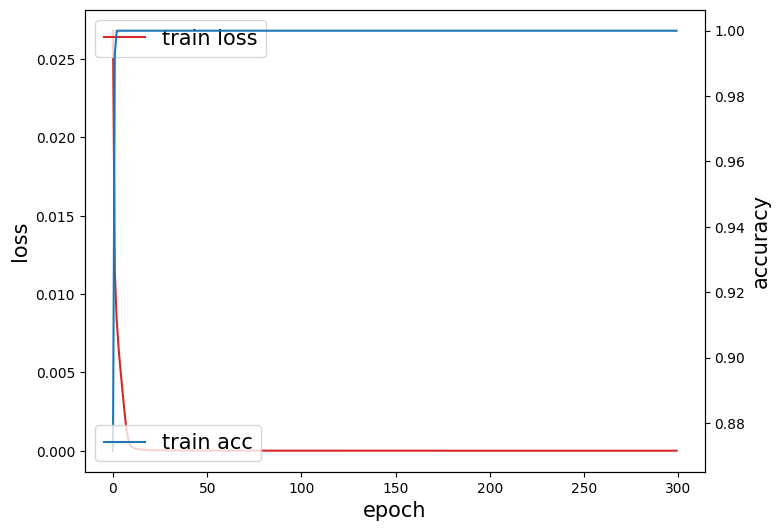

In [33]:
fig, loss_ax = plt.subplots(figsize=(8, 6))
acc_ax = loss_ax.twinx()

loss_ax.plot(TraingHistory.history["loss"], label="train loss", c="tab:red")
loss_ax.set_xlabel("epoch", fontsize=15)
loss_ax.set_ylabel("loss", fontsize=15)
loss_ax.legend(loc="upper left", fontsize=15)

acc_ax.plot(TraingHistory.history["accuracy"], label="train acc", c="tab:blue")
acc_ax.set_ylabel("accuracy", fontsize=15)
acc_ax.legend(loc="lower left", fontsize=15)

plt.show()

## ML5 and ML6 Summary and Deliverables

Answer the following questions for your achievements

### Q1. Please summarize ML5 and ML6.

---

Write down A1 here.

---

### Q2. What skills did you have to develop to accomplish this project?

---

Wirte down A2 here.

---

### Q3. What aspects of this project were the most beneficial for your learning?

---

Wirte down A3 here.

---

### Q4. What challenges did you encounter in completing the project?

---

Typically, when I am completing lab assignments or other homework assignments I prefer to use the VSCode editor. However, for this assignment I had significant difficulties in connecting to Google's servers.

---

### Q5. How did you overcome the challenges or remedy the problems encountered?

---

The first solution I tried to use was to add the Google Colab extension to VSCode. This enabled me to connect to Google's Servers and use a Google GPU server. The next issue was that in this runtime, I did not have access to my local files where my ML3_Code2 output was. I was able to solve this at first by using a GitHub link. However, later on during ML5_Code, I was unable to save the ANN model locally because the runtime was connected to Drive. After this, I decided to just use Google Colab on the web.

---